<a href="https://colab.research.google.com/github/2403a52026-lgtm/ML_LAB_Assignment/blob/main/ML_LAB_11_2403a52026_B_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [3]:
df = pd.read_csv("data (1).csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop(["id","Unnamed: 32"], axis=1)

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [8]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree Accuracy: 0.9385964912280702
Decision Tree ROC-AUC: 0.9323616115296429


In [9]:
ada = AdaBoostClassifier()

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

In [10]:
ada_accuracy = accuracy_score(y_test, ada_pred)
ada_auc = roc_auc_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_accuracy)
print("AdaBoost ROC-AUC:", ada_auc)

AdaBoost Accuracy: 0.9649122807017544
AdaBoost ROC-AUC: 0.9580740255486406


In [11]:
print("Model Comparison")

print("Decision Tree Accuracy:", dt_accuracy)
print("AdaBoost Accuracy:", ada_accuracy)

print("Decision Tree ROC-AUC:", dt_auc)
print("AdaBoost ROC-AUC:", ada_auc)

Model Comparison
Decision Tree Accuracy: 0.9385964912280702
AdaBoost Accuracy: 0.9649122807017544
Decision Tree ROC-AUC: 0.9323616115296429
AdaBoost ROC-AUC: 0.9580740255486406


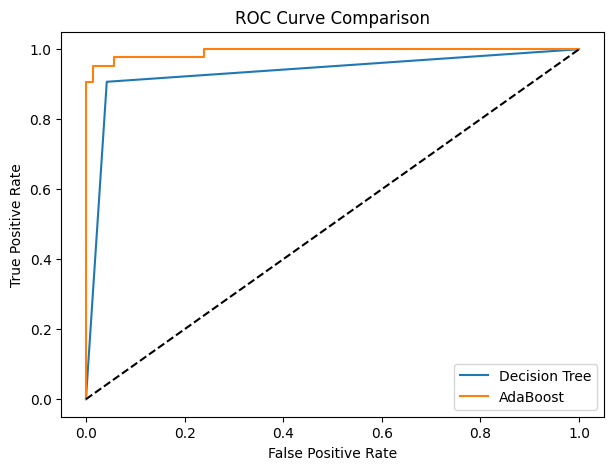

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

dt_prob = dt.predict_proba(X_test)[:, 1]
ada_prob = ada.predict_proba(X_test)[:, 1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)
plt.figure(figsize=(7,5))
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()